# We here try to estimate the parameters of the sterile male population

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.optimize as opt

In [2]:
file_rel = '/home/leo/Documents/These/Codes/SIT_models/Data/df_poly_release.csv'  # Replace with the path to your file
file_capt = '/home/leo/Documents/These/Codes/SIT_models/Data/df_poly_capture.csv'  # Replace with the path to your file
df_rel = pd.read_csv(file_rel, sep=',')
df_capt = pd.read_csv(file_capt, sep=',')

## Lets keep the Onetahi capture and releases only

In [3]:
# Keep only the date, Motu and Nb_ind in the release df and onetahi motu
df_rel = df_rel[['Date', 'Motu', 'Nb_ind']]
df_rel = df_rel[df_rel['Motu'] == 'Onetahi']
df_rel = df_rel.drop(columns=['Motu'])

# Keep only the date, Motu and Nb_ind in the capture df and onetahi motu and then remove the motu column
df_capt = df_capt[['Date', 'Motu', 'Nb_ind']]
df_capt = df_capt[df_capt['Motu'] == 'Onetahi']
df_capt = df_capt.drop(columns=['Motu'])

# Group the capture by date and sum the number of individuals captured without deleting the data on the other columns
df_capt = df_capt.groupby('Date').sum().reset_index()

Since we look at the first release, we look for the capture happening on 2019 only

In [4]:
# Since we look at the first release, we look for the capture happening on 2019 only
df_capt = df_capt[df_capt['Date'].str.contains('2019')]
df_rel = df_rel[df_rel['Date'].str.contains('2019')]

# add one day to the release date to have the first day of capture after release
df_rel['Date'] = pd.to_datetime(df_rel['Date']) + pd.Timedelta(days=1)
df_capt['Date'] = pd.to_datetime(df_capt['Date'])

## Estimation plan

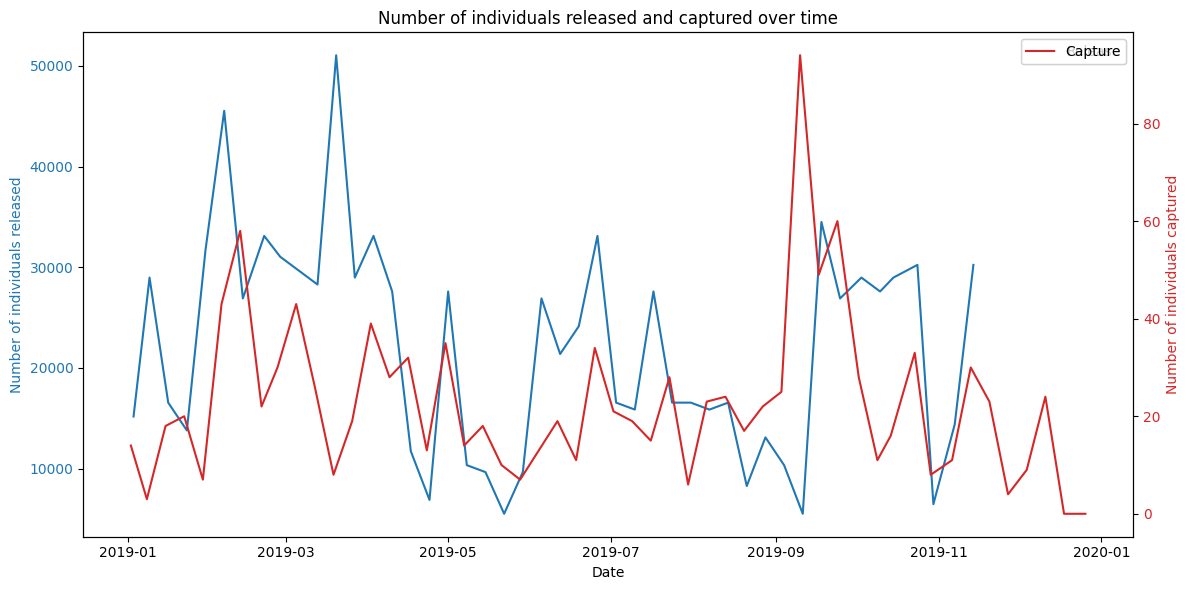

In [5]:
# Let's plot both capture and release with different scqle for the releqse qnd cqpture
fig, ax1 = plt.subplots(figsize=(12, 6))
sns.lineplot(data=df_rel, x='Date', y='Nb_ind', ax=ax1, label='Release', color='tab:blue')
ax1.set_ylabel('Number of individuals released', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2 = ax1.twinx()
sns.lineplot(data=df_capt, x='Date', y='Nb_ind', ax=ax2, label='Capture', color='tab:red')
ax2.set_ylabel('Number of individuals captured', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax1.set_title('Number of individuals released and captured over time')
fig.tight_layout()
plt.show()

In [6]:
#Lets replace the dates by the week number in the year
df_rel['Week'] = df_rel['Date'].dt.isocalendar().week
df_capt['Week'] = df_capt['Date'].dt.isocalendar().week

In [7]:
# Add missing weeks (1..52) to df_rel and set missing releases to 0
weeks = pd.DataFrame({'Week': range(1, 53)})

df_rel = weeks.merge(df_rel, on='Week', how='left')
df_rel['Nb_ind'] = df_rel['Nb_ind'].fillna(0)

# Optional: keep original column order
df_rel = df_rel[['Date', 'Nb_ind', 'Week']].sort_values('Week').reset_index(drop=True)

The goal is simple : given a sequence of release size, we want to estimate them with a Poisson model: each capture is a poisson realisation. We know the time and the size of each intervention, this can be computed in a log likelihood function.

In [17]:
def expected_captures(releases, week, delta):
    releases = (np.sum(releases[releases['Week'] <= week - 2]['Nb_ind'] *( np.exp(-delta * 7 *(week - releases['Week'] - 1)) - np.exp(-delta * 7 *  (week - releases['Week'])))) + releases[releases['Week'] == week-1]['Nb_ind'] (1 -  np.exp(-delta * 7 * (week - releases['Week'] -1))))/delta
    return releases

def loglikelihood(params, releases, captures, week):
    p = params[0]
    delta = params[1]
    ecaptures = expected_captures(releases, week, delta)
    ll = np.sum(captures * (np.log(p) + np.log(ecaptures)) - p * ecaptures)
    return -ll

In [18]:
# Plot the expected captures for delta = 0.139
delta = 0.139
df_capt['Expected_Captures'] = df_capt['Week'].apply(lambda week: expected_captures(df_rel, week, delta))
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_capt, x='Week', y='Nb_ind', label='Observed Captures', color='tab:red')
sns.lineplot(data=df_capt, x='Week', y='Expected_Captures', label='Expected Captures (delta=0.139)', color='tab:blue')
plt.xlabel('Week of the Year')
plt.ylabel('Number of Captures')
plt.title('Observed vs Expected Captures Over Time')
plt.legend()
plt.show()

TypeError: 'Series' object is not callable

We want to maximize the log likelihood. The two unknown parameters are the death rate delta and capture rate p.

In [11]:
val = opt.minimize(loglikelihood, x0 = [0.1,0.139], args = (df_rel, df_capt["Nb_ind"], df_capt["Week"]), bounds= [(0, 1), (0, 1)])

ValueError: Can only compare identically-labeled Series objects